# PD, IRB capital, Vasicek losses, and optimal allocation

This notebook is a compact exploratory workspace for visualising the mapping

```text
quarterly PD -> quarterly expected charge-off
quarterly PD -> annual PD for Basel IRB
annual PD -> Basel asset correlation R(PD_annual)
quarterly PD, R(PD_annual) -> Vasicek loss distribution
annual PD -> Basel IRB capital requirement K_IRB(PD_annual)
quarterly PD, F_L, K_IRB -> optimal allocation alpha_star(PD_quarterly)
```

The default setting is thesis-consistent with `01_simulate_pd_panel.ipynb`: the decision problem is quarterly, so the PD grid is quarterly. Basel IRB and the Basel-implied Vasicek asset correlation use the derived annual PD. Fixed-correlation runs are included only as sensitivity experiments.

## 1. Setup and parameters

The baseline parameters below mirror `simulation/notebooks/01_simulate_pd_panel.ipynb` where they overlap. The main objective uses the analytical linear expected-shortfall penalty.

The `y` and `leverage` values in the setup cell are the single source of truth for this notebook. All main plots and sensitivity plots use those values unless the section is explicitly varying that parameter.

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

# Constants aligned with 01_simulate_pd_panel.ipynb where applicable.
LGD = 0.45
M = 2.5
y = 0.0168
lambda_penalty = 10.0
leverage = 15.0

rho_mode = "basel"  # options: "basel" or "fixed"
rho_fixed = 0.12    # only used when rho_mode == "fixed"

PD_CLIP_LOW = 1e-6
PD_CLIP_HIGH = 0.99

# Quarterly PD grid, matching the simulation notebook's calibrated support.
pd_quarterly_min = 0.001
pd_quarterly_max = 0.025
pd_grid = np.linspace(pd_quarterly_min, pd_quarterly_max, 300)
pd_annual_grid = 1 - (1 - pd_grid) ** 4


alpha_grid = np.linspace(0, 1, 1001)
# Coarser grids keep sensitivity and Monte Carlo comparison cells responsive.
sensitivity_pd_grid = np.linspace(pd_quarterly_min, pd_quarterly_max, 100)
sensitivity_alpha_grid = np.linspace(0, 1, 251)
coarse_pd_grid = np.linspace(pd_quarterly_min, pd_quarterly_max, 60)
coarse_alpha_grid = np.linspace(0, 1, 101)

rng = np.random.default_rng(42)

### Core functions

These functions keep the notebook modular. They accept scalars and arrays where useful, clip near-problematic boundaries, and make the frequency convention explicit:

- `pd_quarterly` is the one-quarter PD used for expected quarterly losses and the Vasicek default threshold.
- `pd_annual = 1 - (1 - pd_quarterly) ** 4` is the one-year PD used for Basel IRB capital and Basel-implied asset correlation.

In [7]:
def _asarray(x):
    """Return x as a NumPy array without losing scalar information upstream."""
    return np.asarray(x, dtype=float)


def _maybe_scalar(value, template):
    """Return a scalar when the original input was scalar, otherwise an array."""
    arr = np.asarray(value)
    return arr.item() if np.isscalar(template) else arr


def clip_pd(pd):
    """Clip probabilities of default away from 0 and 1."""
    clipped = np.clip(_asarray(pd), PD_CLIP_LOW, PD_CLIP_HIGH)
    return _maybe_scalar(clipped, pd)


def clip_rho(rho):
    """Clip asset correlation away from degenerate 0 and 1 boundaries."""
    clipped = np.clip(_asarray(rho), 1e-8, 1 - 1e-8)
    return _maybe_scalar(clipped, rho)


def pd_quarterly_to_annual(pd_quarterly):
    """Convert a one-quarter PD to a one-year PD."""
    pd_q = _asarray(clip_pd(pd_quarterly))
    pd_a = 1 - (1 - pd_q) ** 4
    pd_a = clip_pd(pd_a)
    return _maybe_scalar(pd_a, pd_quarterly)


def basel_correlation(pd_annual):
    """Basel corporate asset correlation R(PD_annual)."""
    pd_a = _asarray(clip_pd(pd_annual))
    weight = (1 - np.exp(-50 * pd_a)) / (1 - np.exp(-50))
    rho = 0.12 * weight + 0.24 * (1 - weight)
    return _maybe_scalar(rho, pd_annual)


def get_rho(pd_annual, rho_mode="basel", rho_fixed=0.12):
    """Return Basel-implied or fixed asset correlation using annual PD."""
    if rho_mode == "basel":
        return basel_correlation(pd_annual)
    if rho_mode == "fixed":
        if np.isscalar(pd_annual):
            return float(clip_rho(rho_fixed))
        return np.full_like(_asarray(pd_annual), float(clip_rho(rho_fixed)), dtype=float)
    raise ValueError("rho_mode must be either 'basel' or 'fixed'")


def get_rho_from_pd_quarterly(pd_quarterly, rho_mode="basel", rho_fixed=0.12):
    """Return asset correlation for a quarterly PD by annualising first."""
    pd_annual = pd_quarterly_to_annual(pd_quarterly)
    return get_rho(pd_annual, rho_mode=rho_mode, rho_fixed=rho_fixed)


def maturity_adjustment(pd_annual, M=2.5):
    """Basel maturity adjustment for corporate exposures, using annual PD."""
    pd_a = _asarray(clip_pd(pd_annual))
    b = (0.11852 - 0.05478 * np.log(pd_a)) ** 2
    adj = (1 + (M - 2.5) * b) / (1 - 1.5 * b)
    return _maybe_scalar(adj, pd_annual)


def k_irb(pd_annual, lgd=LGD, M=M):
    """Basel IRB capital requirement per unit exposure using annual PD."""
    pd_a = _asarray(clip_pd(pd_annual))
    R = _asarray(clip_rho(basel_correlation(pd_a)))
    z = norm.ppf(pd_a) / np.sqrt(1 - R) + np.sqrt(R / (1 - R)) * norm.ppf(0.999)
    capital = lgd * (norm.cdf(z) - pd_a) * maturity_adjustment(pd_a, M=M)
    return _maybe_scalar(np.maximum(capital, 0), pd_annual)


def k_irb_from_pd_quarterly(pd_quarterly, lgd=LGD, M=M):
    """Basel IRB capital for a quarterly PD by annualising first."""
    return k_irb(pd_quarterly_to_annual(pd_quarterly), lgd=lgd, M=M)


def vasicek_cdf(x, pd_quarterly, rho):
    """CDF of the asymptotic quarterly Vasicek default-rate distribution."""
    x_arr = _asarray(x)
    pd_q = _asarray(clip_pd(pd_quarterly))
    rho_c = _asarray(clip_rho(rho))
    x_c = np.clip(x_arr, 1e-12, 1 - 1e-12)
    cdf = norm.cdf((norm.ppf(x_c) * np.sqrt(1 - rho_c) - norm.ppf(pd_q)) / np.sqrt(rho_c))
    cdf = np.where(x_arr <= 0, 0.0, np.where(x_arr >= 1, 1.0, cdf))
    return _maybe_scalar(cdf, x)


def vasicek_quantile(q, pd_quarterly, rho):
    """Quantile function for the quarterly Vasicek default-rate distribution."""
    q_c = np.clip(_asarray(q), 1e-12, 1 - 1e-12)
    pd_q = _asarray(clip_pd(pd_quarterly))
    rho_c = _asarray(clip_rho(rho))
    quantile = norm.cdf((norm.ppf(pd_q) + np.sqrt(rho_c) * norm.ppf(q_c)) / np.sqrt(1 - rho_c))
    return _maybe_scalar(quantile, q)


def vasicek_loss_from_factor(Y, pd_quarterly, rho):
    """Conditional quarterly default rate L(Y; PD_q, rho(PD_annual))."""
    pd_q = _asarray(clip_pd(pd_quarterly))
    rho_c = _asarray(clip_rho(rho))
    loss = norm.cdf((norm.ppf(pd_q) - np.sqrt(rho_c) * _asarray(Y)) / np.sqrt(1 - rho_c))
    return _maybe_scalar(loss, Y)


def vasicek_expected_shortfall_above_threshold(x, pd_quarterly, rho):
    """Analytical E[(L - x)^+] for the quarterly Vasicek default-rate distribution.

    Edge cases follow directly from the payoff: if x <= 0,
    E[(L - x)^+] = E[L] - x = PD_q - x; if x >= 1, it is 0.
    """
    pd_q = float(clip_pd(pd_quarterly))
    rho_c = float(clip_rho(rho))
    x_arr = _asarray(x)
    es = np.zeros_like(x_arr, dtype=float)

    below = x_arr <= 0
    above = x_arr >= 1
    middle = ~(below | above)

    es = np.where(below, pd_q - x_arr, es)
    if np.any(middle):
        x_mid = np.clip(x_arr[middle], 1e-12, 1 - 1e-12)
        y_x = (norm.ppf(pd_q) - np.sqrt(1 - rho_c) * norm.ppf(x_mid)) / np.sqrt(rho_c)
        points = np.column_stack([np.full_like(y_x, norm.ppf(pd_q)), y_x])
        joint_prob = multivariate_normal.cdf(
            points,
            mean=[0, 0],
            cov=[[1, np.sqrt(rho_c)], [np.sqrt(rho_c), 1]],
        )
        es[middle] = joint_prob - x_mid * norm.cdf(y_x)

    es = np.maximum(es, 0.0)
    return _maybe_scalar(es, x)


def shortfall_threshold(alpha, pd_quarterly, y=y, lgd=LGD, leverage=leverage):
    """Quarterly default-rate threshold above which capital shortfall is active.

    Expected losses and the default-rate threshold use quarterly PD. Required
    regulatory capital uses annual PD through k_irb_from_pd_quarterly().
    """
    alpha_value = float(alpha)
    leverage_value = float(leverage)
    if alpha_value <= 0:
        return np.inf
    if leverage_value <= 0:
        raise ValueError("leverage must be positive")

    kirb = k_irb_from_pd_quarterly(pd_quarterly, lgd=lgd, M=M)
    numerator = (1 - alpha_value) + leverage_value * alpha_value * y - leverage_value * alpha_value * kirb
    denominator = leverage_value * alpha_value * lgd
    return numerator / denominator


def objective(
    alpha,
    pd_quarterly,
    rho_mode="basel",
    rho_fixed=0.12,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
    mc_draws=None,
):
    """Allocation objective U(alpha; PD_q), optionally with leverage.

    Terminal capital uses quarterly realised losses. Basel IRB capital and
    Basel-implied Vasicek rho use annual PD derived from PD_q.
    """
    leverage_value = float(leverage)
    if leverage_value <= 0:
        raise ValueError("leverage must be positive")

    alpha_arr = _asarray(alpha)
    pd_q = float(clip_pd(pd_quarterly))
    rho = float(clip_rho(get_rho_from_pd_quarterly(pd_q, rho_mode=rho_mode, rho_fixed=rho_fixed)))
    expected_terminal_capital = 1 + leverage_value * alpha_arr * (y - lgd * pd_q)

    utility = np.full_like(alpha_arr, 1.0, dtype=float)
    positive = alpha_arr > 0
    if np.any(positive):
        alpha_pos = alpha_arr[positive]
        kirb = k_irb_from_pd_quarterly(pd_q, lgd=lgd, M=M)
        x = (
            (1 - alpha_pos)
            + leverage_value * alpha_pos * y
            - leverage_value * alpha_pos * kirb
        ) / (leverage_value * alpha_pos * lgd)
        if penalty_type == "linear":
            es = vasicek_expected_shortfall_above_threshold(x, pd_q, rho)
            expected_shortfall = leverage_value * alpha_pos * lgd * es
            penalty = lambda_penalty * expected_shortfall
        elif penalty_type == "squared_mc":
            if mc_draws is None:
                mc_draws = rng.standard_normal(50_000)
            losses = vasicek_loss_from_factor(mc_draws, pd_q, rho)
            shortfalls = (
                leverage_value
                * alpha_pos[:, None]
                * lgd
                * np.maximum(losses[None, :] - x[:, None], 0)
            )
            penalty = lambda_penalty * np.mean(shortfalls ** 2, axis=1)
        else:
            raise ValueError("penalty_type must be either 'linear' or 'squared_mc'")
        utility[positive] = expected_terminal_capital[positive] - penalty

    return _maybe_scalar(utility, alpha)

from scipy.optimize import minimize_scalar

def optimal_alpha(
    pd_quarterly,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,  # kept only for return_curve plotting, not for the optimum itself
    penalty_type="linear",
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    mc_draws=None,
    return_curve=True,
):
    """Solve for the continuous optimum instead of an argmax over a discrete grid."""

    def neg_utility(a):
        return -objective(
            np.array([a]), pd_quarterly, rho_mode=rho_mode, rho_fixed=rho_fixed,
            y=y, lgd=lgd, lambda_penalty=lambda_penalty, leverage=leverage,
            penalty_type=penalty_type, mc_draws=mc_draws,
        )[0]

    result = minimize_scalar(neg_utility, bounds=(1e-9, 1.0), method="bounded",
                              options={"xatol": 1e-10})
    alpha_interior, u_interior = result.x, -result.fun
    u_at_zero = 1.0  # objective() defines utility(0) = 1 exactly

    if u_at_zero >= u_interior:
        alpha_star, u_star = 0.0, u_at_zero
    else:
        alpha_star, u_star = alpha_interior, u_interior

    if return_curve:
        curve = objective(alpha_grid, pd_quarterly, rho_mode=rho_mode, rho_fixed=rho_fixed,
                           y=y, lgd=lgd, lambda_penalty=lambda_penalty, leverage=leverage,
                           penalty_type=penalty_type, mc_draws=mc_draws)
        return alpha_star, u_star, curve
    return alpha_star, u_star

def optimal_alpha_old(
    pd_quarterly,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    penalty_type="linear",
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    mc_draws=None,
    return_curve=True,
):
    """Evaluate the objective over a grid and return the optimum."""
    curve = objective(
        alpha_grid,
        pd_quarterly,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
        mc_draws=mc_draws,
    )
    idx = int(np.nanargmax(curve))
    if return_curve:
        return float(alpha_grid[idx]), float(curve[idx]), curve
    return float(alpha_grid[idx]), float(curve[idx])


def percent_axis(ax, axis="x"):
    """Format an axis whose data are proportions as percentages."""
    formatter = plt.FuncFormatter(lambda value, _: f"{100 * value:.0f}%")
    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    else:
        ax.yaxis.set_major_formatter(formatter)


def rho_label(rho_mode=rho_mode, rho_fixed=rho_fixed):
    """Readable label for the current correlation mode."""
    if rho_mode == "basel":
        return "Basel-implied rho from annual PD"
    return f"fixed rho = {rho_fixed:.2f}"

## 2. Basel IRB mapping

This section isolates the regulatory mappings. The x-axis is quarterly PD because that is the decision frequency. Annual PD is derived from quarterly PD for the Basel corporate correlation and IRB capital formulas.

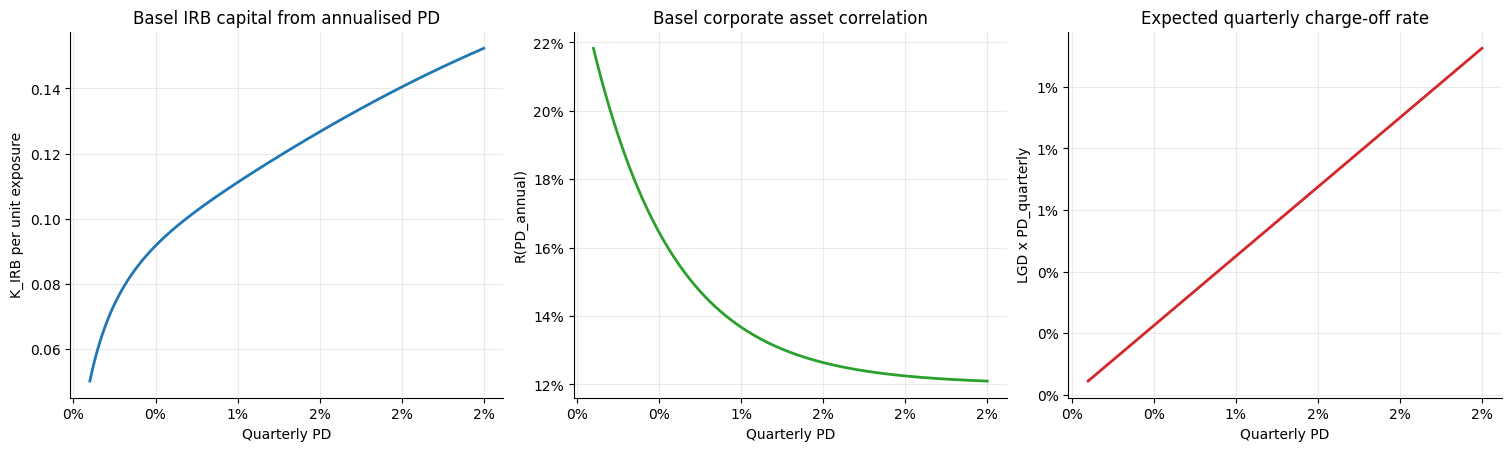

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

axes[0].plot(pd_grid, k_irb_from_pd_quarterly(pd_grid), color="tab:blue", lw=2)
axes[0].set_title("Basel IRB capital from annualised PD")
axes[0].set_xlabel("Quarterly PD")
axes[0].set_ylabel("K_IRB per unit exposure")
percent_axis(axes[0], "x")

axes[1].plot(pd_grid, basel_correlation(pd_quarterly_to_annual(pd_grid)), color="tab:green", lw=2)
axes[1].set_title("Basel corporate asset correlation")
axes[1].set_xlabel("Quarterly PD")
axes[1].set_ylabel("R(PD_annual)")
percent_axis(axes[1], "x")
percent_axis(axes[1], "y")

axes[2].plot(pd_grid, LGD * pd_grid, color="tab:red", lw=2)
axes[2].set_title("Expected quarterly charge-off rate")
axes[2].set_xlabel("Quarterly PD")
axes[2].set_ylabel("LGD x PD_quarterly")
percent_axis(axes[2], "x")
percent_axis(axes[2], "y")

plt.show()

## 3. Vasicek loss distribution

The Vasicek distribution describes the limiting quarterly portfolio default rate under a one-factor Gaussian credit model. The default threshold uses quarterly PD. In the baseline mode, the asset correlation is Basel-implied from the derived annual PD.

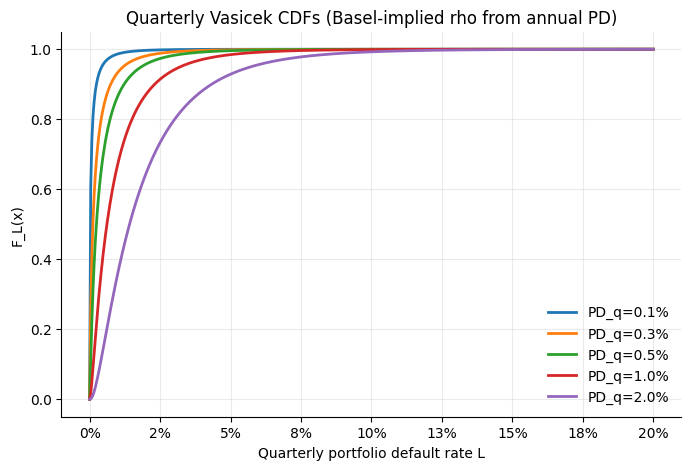

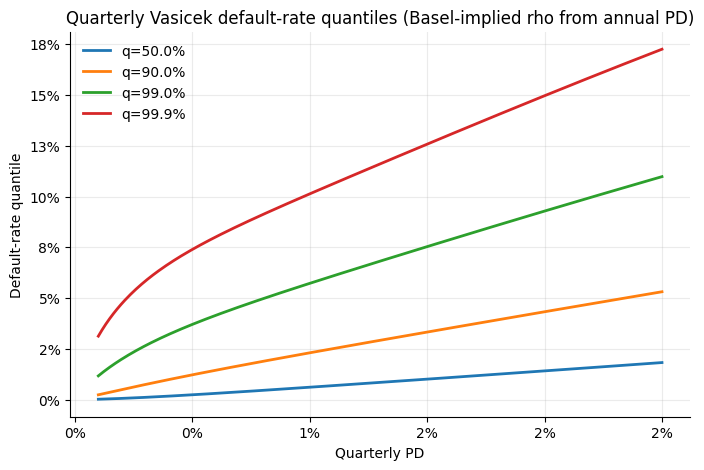

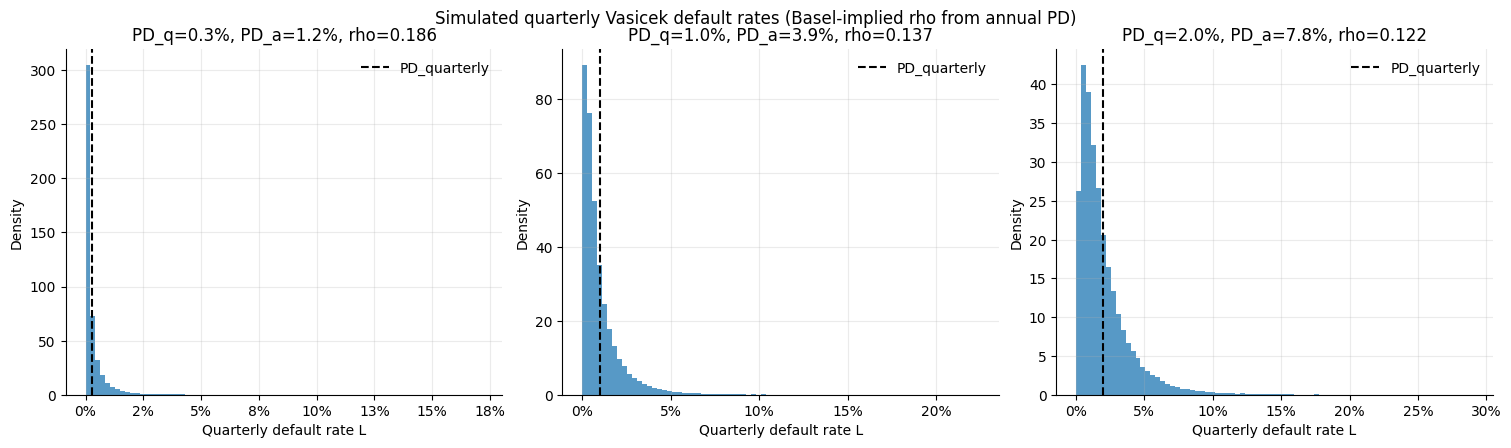

In [9]:
selected_pds = [0.001, 0.003, 0.005, 0.010, 0.020]
x_grid = np.linspace(0, 0.20, 500)
quantile_levels = [0.50, 0.90, 0.99, 0.999]

fig, ax = plt.subplots(figsize=(8, 5))
for pd_value in selected_pds:
    rho_value = get_rho_from_pd_quarterly(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed)
    ax.plot(x_grid, vasicek_cdf(x_grid, pd_value, rho_value), lw=2, label=f"PD_q={100*pd_value:.1f}%")

ax.set_title(f"Quarterly Vasicek CDFs ({rho_label()})")
ax.set_xlabel("Quarterly portfolio default rate L")
ax.set_ylabel("F_L(x)")
percent_axis(ax, "x")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for q in quantile_levels:
    q_values = np.array([
        vasicek_quantile(q, pd_value, get_rho_from_pd_quarterly(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed))
        for pd_value in pd_grid
    ])
    ax.plot(pd_grid, q_values, lw=2, label=f"q={100*q:.1f}%")

ax.set_title(f"Quarterly Vasicek default-rate quantiles ({rho_label()})")
ax.set_xlabel("Quarterly PD")
ax.set_ylabel("Default-rate quantile")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
sim_pds = [0.003, 0.010, 0.020]
Y_sim = rng.standard_normal(80_000)

for ax, pd_value in zip(axes, sim_pds):
    rho_value = get_rho_from_pd_quarterly(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed)
    losses = vasicek_loss_from_factor(Y_sim, pd_value, rho_value)
    ax.hist(losses, bins=80, density=True, color="tab:blue", alpha=0.75)
    ax.axvline(pd_value, color="black", lw=1.5, ls="--", label="PD_quarterly")
    ax.set_title(f"PD_q={100*pd_value:.1f}%, PD_a={100*pd_quarterly_to_annual(pd_value):.1f}%, rho={rho_value:.3f}")
    ax.set_xlabel("Quarterly default rate L")
    ax.set_ylabel("Density")
    percent_axis(ax, "x")
    ax.legend()

fig.suptitle(f"Simulated quarterly Vasicek default rates ({rho_label()})", y=1.03)
plt.show()

## 4. Shortfall threshold

The threshold `x(alpha, PD_quarterly, leverage)` is the realised quarterly portfolio default rate above which the regulatory-capital shortfall becomes active. Leverage belongs in this threshold because it scales risky exposure, terminal capital, and required regulatory capital.

When the threshold is above 1, shortfall is essentially impossible. When it is below 0, shortfall is always active.

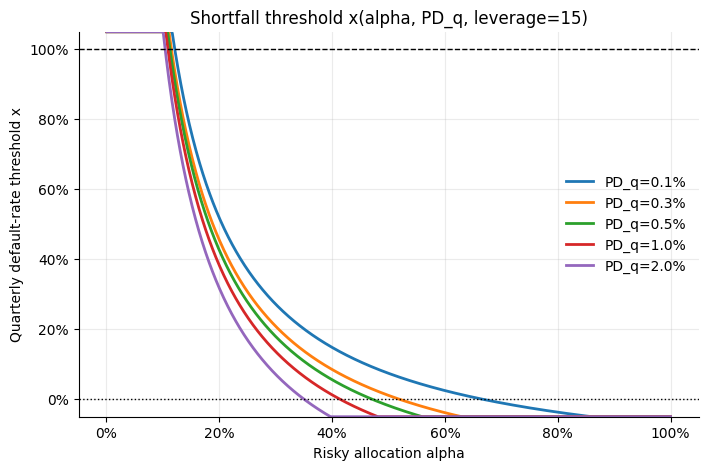

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
alpha_positive = alpha_grid[1:]

for pd_value in selected_pds:
    thresholds = np.array([
        shortfall_threshold(alpha, pd_value, y=y, lgd=LGD, leverage=leverage)
        for alpha in alpha_positive
    ])
    visible_thresholds = np.clip(thresholds, -0.05, 1.05)
    ax.plot(alpha_positive, visible_thresholds, lw=2, label=f"PD_q={100*pd_value:.1f}%")

ax.axhline(1, color="black", lw=1, ls="--")
ax.axhline(0, color="black", lw=1, ls=":")
ax.set_title(f"Shortfall threshold x(alpha, PD_q, leverage={leverage:g})")
ax.set_xlabel("Risky allocation alpha")
ax.set_ylabel("Quarterly default-rate threshold x")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.show()

## 5. Expected shortfall term

The expected shortfall term is `E[(L - x(alpha, PD_quarterly))^+]`. It rises when either the threshold falls or the Vasicek tail becomes heavier. The default-rate threshold uses quarterly PD; the Basel-implied rho uses annual PD.

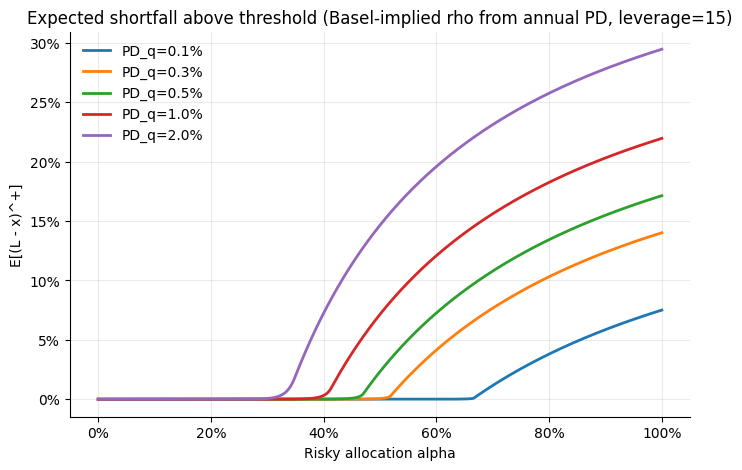

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for pd_value in selected_pds:
    rho_value = get_rho_from_pd_quarterly(pd_value, rho_mode=rho_mode, rho_fixed=rho_fixed)
    es_values = np.array([
        vasicek_expected_shortfall_above_threshold(
            shortfall_threshold(alpha, pd_value, y=y, lgd=LGD, leverage=leverage),
            pd_value,
            rho_value,
        ) if alpha > 0 else 0.0
        for alpha in alpha_grid
    ])
    ax.plot(alpha_grid, es_values, lw=2, label=f"PD_q={100*pd_value:.1f}%")

ax.set_title(f"Expected shortfall above threshold ({rho_label()}, leverage={leverage:g})")
ax.set_xlabel("Risky allocation alpha")
ax.set_ylabel("E[(L - x)^+]")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

## 6. Allocation objective

For each selected quarterly PD, the objective balances expected risky return against expected quarterly credit losses and the regulatory shortfall penalty. IRB capital and Basel-implied rho use annual PD derived from the quarterly PD.

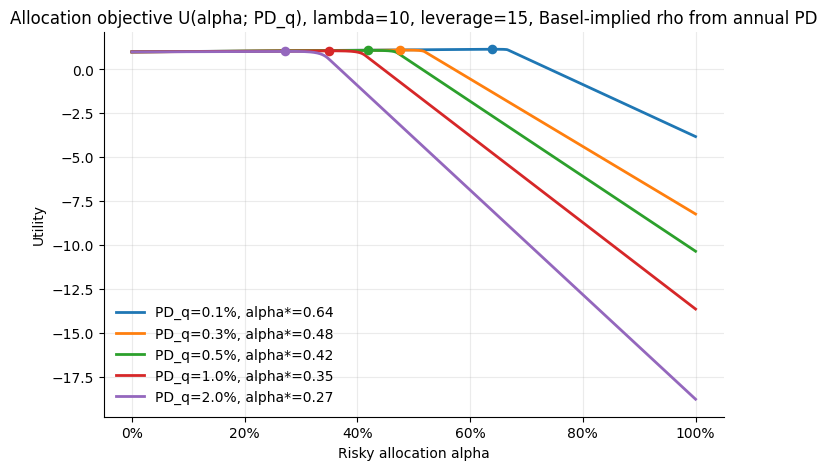

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

for pd_value in selected_pds:
    alpha_star, max_u, curve = optimal_alpha(
        pd_value,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        leverage=leverage
    )
    ax.plot(alpha_grid, curve, lw=2, label=f"PD_q={100*pd_value:.1f}%, alpha*={alpha_star:.2f}")
    ax.scatter([alpha_star], [max_u], s=35, zorder=3)

ax.set_title(f"Allocation objective U(alpha; PD_q), lambda={lambda_penalty:g}, leverage={leverage:g}, {rho_label()}")
ax.set_xlabel("Risky allocation alpha")
ax.set_ylabel("Utility")
percent_axis(ax, "x")
ax.legend()
plt.show()

## 7. Quarterly-PD-to-optimal-allocation mapping

The main object of interest is the decision rule `PD_quarterly -> alpha_star`. The companion panels show expected quarterly charge-offs, annual PD, IRB capital requirement, and maximum utility at the chosen allocation.

In [13]:
allocation_rows = []
for pd_value in pd_grid:
    pd_annual_value = pd_quarterly_to_annual(pd_value)
    alpha_star, max_u = optimal_alpha(
        pd_value,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        return_curve=False,
        leverage=leverage
    )
    allocation_rows.append({
        "PD_quarterly": pd_value,
        "PD_annual": pd_annual_value,
        "alpha_star": alpha_star,
        "max_utility": max_u,
        "expected_charge_off_quarterly": LGD * pd_value,
        "K_IRB": k_irb(pd_annual_value),
        "rho": get_rho(pd_annual_value, rho_mode=rho_mode, rho_fixed=rho_fixed),
    })

allocation_df = pd.DataFrame(allocation_rows)
allocation_df.head()

,PD_quarterly,PD_annual,alpha_star,max_utility,expected_charge_off_quarterly,K_IRB,rho
0,0.001000,0.003994,0.639710,1.152082,0.000450,0.050138,0.218277
1,0.001080,0.004314,0.626381,1.148446,0.000486,0.052013,0.216717
2,0.001161,0.004634,0.614211,1.145117,0.000522,0.053782,0.215182
3,0.001241,0.004954,0.603043,1.142051,0.000558,0.055456,0.213671
4,0.001321,0.005274,0.592750,1.139216,0.000594,0.057043,0.212185


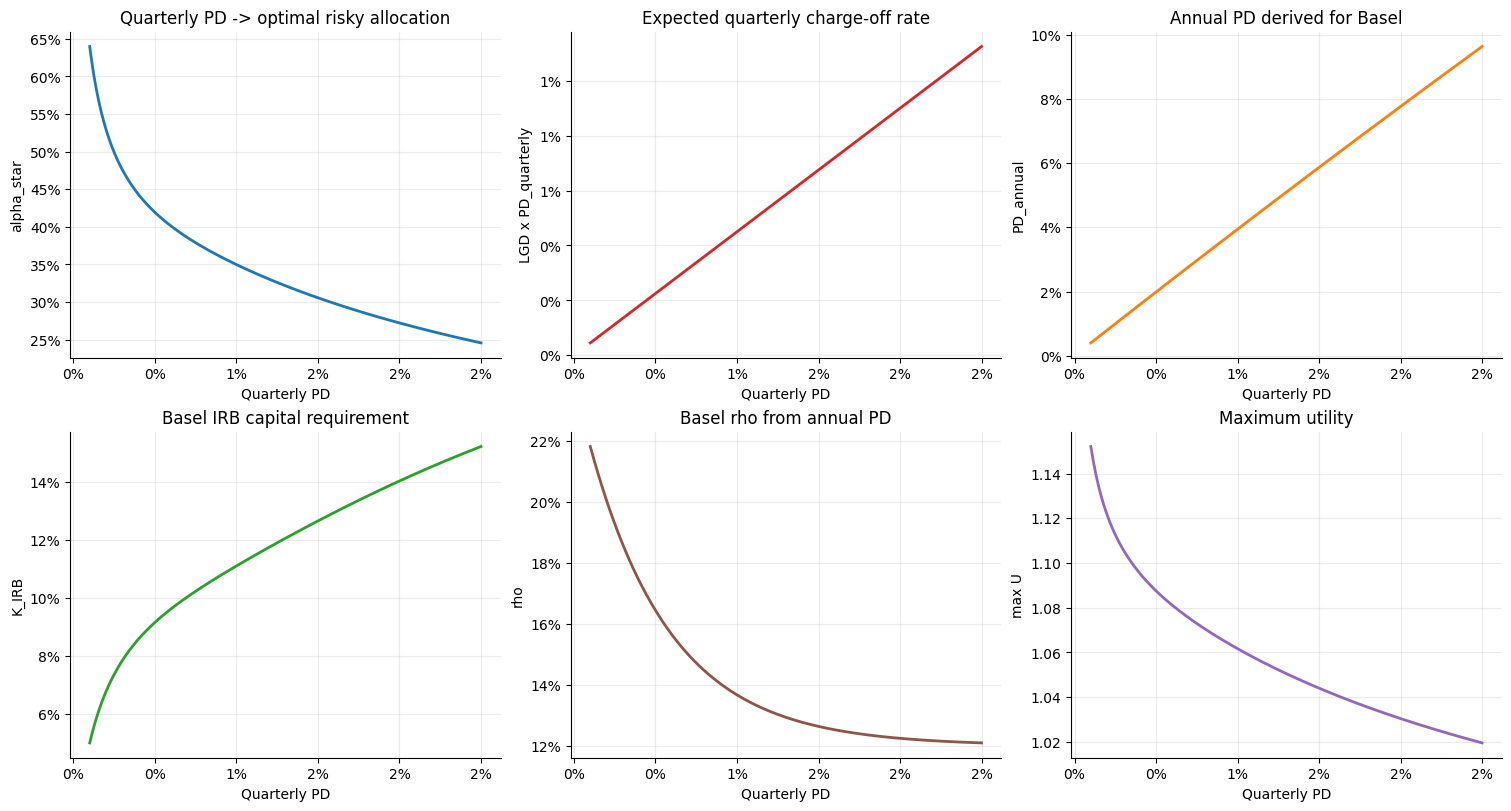

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].plot(allocation_df["PD_quarterly"], allocation_df["alpha_star"], color="tab:blue", lw=2)
axes[0, 0].set_title("Quarterly PD -> optimal risky allocation")
axes[0, 0].set_xlabel("Quarterly PD")
axes[0, 0].set_ylabel("alpha_star")
percent_axis(axes[0, 0], "x")
percent_axis(axes[0, 0], "y")

axes[0, 1].plot(allocation_df["PD_quarterly"], allocation_df["expected_charge_off_quarterly"], color="tab:red", lw=2)
axes[0, 1].set_title("Expected quarterly charge-off rate")
axes[0, 1].set_xlabel("Quarterly PD")
axes[0, 1].set_ylabel("LGD x PD_quarterly")
percent_axis(axes[0, 1], "x")
percent_axis(axes[0, 1], "y")

axes[0, 2].plot(allocation_df["PD_quarterly"], allocation_df["PD_annual"], color="tab:orange", lw=2)
axes[0, 2].set_title("Annual PD derived for Basel")
axes[0, 2].set_xlabel("Quarterly PD")
axes[0, 2].set_ylabel("PD_annual")
percent_axis(axes[0, 2], "x")
percent_axis(axes[0, 2], "y")

axes[1, 0].plot(allocation_df["PD_quarterly"], allocation_df["K_IRB"], color="tab:green", lw=2)
axes[1, 0].set_title("Basel IRB capital requirement")
axes[1, 0].set_xlabel("Quarterly PD")
axes[1, 0].set_ylabel("K_IRB")
percent_axis(axes[1, 0], "x")
percent_axis(axes[1, 0], "y")

axes[1, 1].plot(allocation_df["PD_quarterly"], allocation_df["rho"], color="tab:brown", lw=2)
axes[1, 1].set_title("Basel rho from annual PD")
axes[1, 1].set_xlabel("Quarterly PD")
axes[1, 1].set_ylabel("rho")
percent_axis(axes[1, 1], "x")
percent_axis(axes[1, 1], "y")

axes[1, 2].plot(allocation_df["PD_quarterly"], allocation_df["max_utility"], color="tab:purple", lw=2)
axes[1, 2].set_title("Maximum utility")
axes[1, 2].set_xlabel("Quarterly PD")
axes[1, 2].set_ylabel("max U")
percent_axis(axes[1, 2], "x")

plt.show()

## 8. Sensitivity experiments

These experiments are meant for intuition. The Basel-implied correlation case is the thesis-consistent baseline; fixed correlations are useful for diagnosing how much of the allocation rule comes from correlation assumptions versus expected losses and regulatory capital. The sensitivity cells use coarser PD and alpha grids so they remain quick to rerun while preserving the shape of the decision rule.
Unless a section is explicitly varying leverage, these sensitivity plots use the top-level `leverage` value from the setup cell.


### 8.1 Different penalty weights

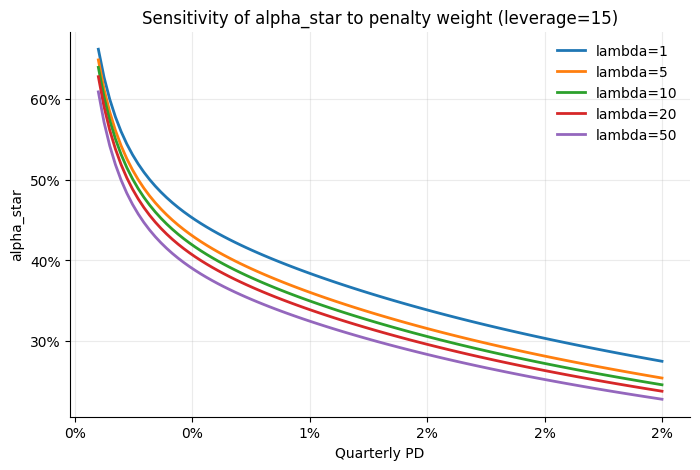

In [16]:
def alpha_star_curve(pd_quarterly_values, alpha_grid=alpha_grid, leverage=leverage, **kwargs):
    """Convenience helper for sensitivity plots over quarterly PD values."""
    return np.array([
        optimal_alpha(
            pd_value,
            alpha_grid=alpha_grid,
            leverage=leverage,
            return_curve=False,
            **kwargs,
        )[0]
        for pd_value in pd_quarterly_values
    ])

lambda_values = [1, 5, 10, 20, 50]

fig, ax = plt.subplots(figsize=(8, 5))
for lam in lambda_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="basel",
        rho_fixed=rho_fixed,
        penalty_type="linear",
        y=y,
        lambda_penalty=lam,
        alpha_grid=sensitivity_alpha_grid,
        leverage=leverage
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"lambda={lam:g}")

ax.set_title(f"Sensitivity of alpha_star to penalty weight (leverage={leverage:g})")
ax.set_xlabel("Quarterly PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

### 8.2 Basel versus fixed asset correlation

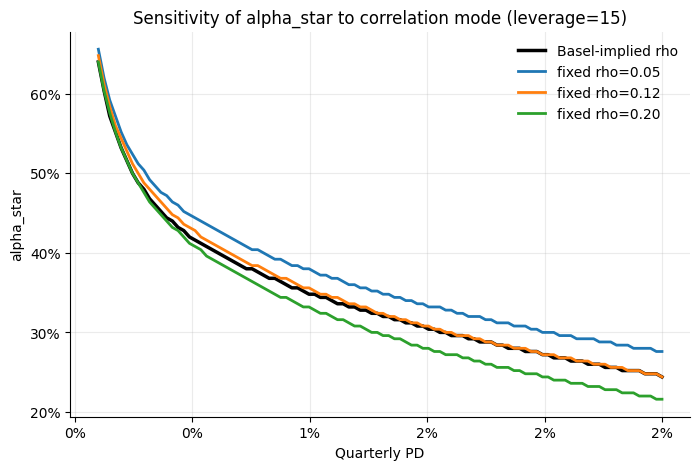

In [132]:
fixed_rho_values = [0.05, 0.12, 0.20]

fig, ax = plt.subplots(figsize=(8, 5))
curve = alpha_star_curve(
    sensitivity_pd_grid,
    rho_mode="basel",
    rho_fixed=rho_fixed,
    penalty_type="linear",
    y=y,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    alpha_grid=sensitivity_alpha_grid,
)
ax.plot(sensitivity_pd_grid, curve, lw=2.5, color="black", label="Basel-implied rho")

for fixed_rho in fixed_rho_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="fixed",
        rho_fixed=fixed_rho,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        alpha_grid=sensitivity_alpha_grid,
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"fixed rho={fixed_rho:.2f}")

ax.set_title(f"Sensitivity of alpha_star to correlation mode (leverage={leverage:g})")
ax.set_xlabel("Quarterly PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

### 8.3 Different yields

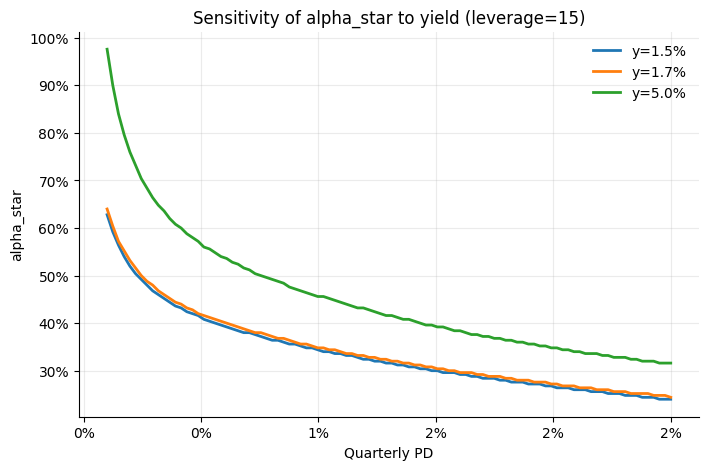

In [133]:
yield_values = list(dict.fromkeys([0.015, y, 0.05]))

fig, ax = plt.subplots(figsize=(8, 5))
for y_value in yield_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="basel",
        rho_fixed=rho_fixed,
        penalty_type="linear",
        y=y_value,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        alpha_grid=sensitivity_alpha_grid,
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"y={100*y_value:.1f}%")

ax.set_title(f"Sensitivity of alpha_star to yield (leverage={leverage:g})")
ax.set_xlabel("Quarterly PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend()
plt.show()

## 9. Leverage sensitivity

The baseline thesis version is unleveraged with `leverage = 1.0`. In this optional sensitivity, leverage is interpreted as risky loan exposure per unit of capital allocated: exposure is `leverage * alpha`. Higher leverage increases both expected terminal capital exposure and the regulatory shortfall exposure; the plot shows how that changes the implied `PD -> alpha_star` rule.

This is the only sensitivity section that intentionally overrides the top-level `leverage` value, because leverage is the parameter being varied. It still uses the top-level `y` and `lambda_penalty`.


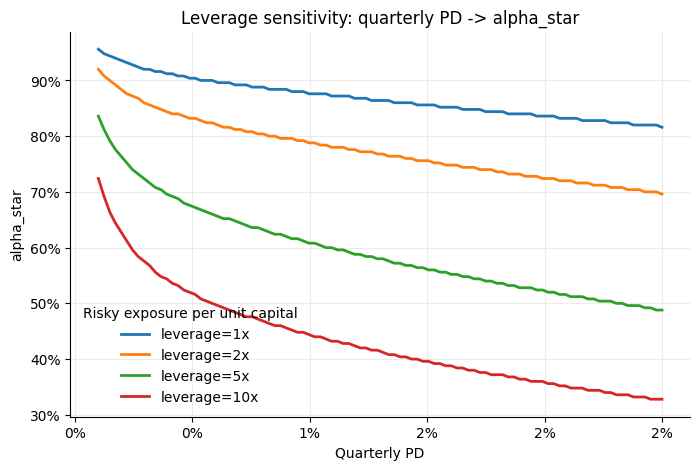

In [134]:
leverage_values = [1, 2, 5, 10]

fig, ax = plt.subplots(figsize=(8, 5))
for leverage_value in leverage_values:
    curve = alpha_star_curve(
        sensitivity_pd_grid,
        rho_mode="basel",
        rho_fixed=rho_fixed,
        penalty_type="linear",
        y=y,
        lambda_penalty=lambda_penalty,
        leverage=leverage_value,
        alpha_grid=sensitivity_alpha_grid,
    )
    ax.plot(sensitivity_pd_grid, curve, lw=2, label=f"leverage={leverage_value:g}x")

ax.set_title("Leverage sensitivity: quarterly PD -> alpha_star")
ax.set_xlabel("Quarterly PD")
ax.set_ylabel("alpha_star")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend(title="Risky exposure per unit capital")
plt.show()

## Section 10: Forecast error, allocation distortion and regret

This section separates the prediction step from the evaluation step. The forecasted quarterly PD determines the allocation chosen by the model. The true quarterly PD determines the realised consequences of that allocation.

The oracle allocation is the allocation that would be chosen if the true quarterly PD were known. The forecast-based allocation is the allocation chosen using the model's predicted quarterly PD. Both allocations are then evaluated under the same true quarterly-PD objective. Basel IRB capital and Basel-implied rho are computed from annual PD derived from the relevant quarterly PD.

```text
pd_hat_quarterly chooses the action.
pd_true_quarterly judges the consequence.
```

Unless explicitly varied, this section uses the top-level `y`, `lambda_penalty`, and `leverage` values from the setup cell.

In [18]:
def objective_under_true_pd(
    alpha,
    pd_true_quarterly,
    rho_mode="basel",
    rho_fixed=0.12,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
    mc_draws=None,
):
    """Evaluate utility under the true quarterly PD environment.

    Expected realised losses use quarterly PD. Vasicek rho and IRB capital use
    annual PD derived from the true quarterly PD.
    """
    leverage_value = float(leverage)
    if leverage_value <= 0:
        raise ValueError("leverage must be positive")

    alpha_arr = _asarray(alpha)
    pd_true_q = float(clip_pd(pd_true_quarterly))
    expected_terminal_capital = 1 + leverage_value * alpha_arr * (y - lgd * pd_true_q)
    utility = np.full_like(alpha_arr, 1.0, dtype=float)

    positive = alpha_arr > 0
    if np.any(positive):
        kirb_true = k_irb_from_pd_quarterly(pd_true_q, lgd=lgd, M=M)
        x = (
            (1 - alpha_arr[positive])
            + leverage_value * alpha_arr[positive] * y
            - leverage_value * alpha_arr[positive] * kirb_true
        ) / (leverage_value * alpha_arr[positive] * lgd)

        rho_true = get_rho_from_pd_quarterly(pd_true_q, rho_mode=rho_mode, rho_fixed=rho_fixed)

        if penalty_type == "linear":
            es_true = vasicek_expected_shortfall_above_threshold(x, pd_true_q, rho_true)
            utility[positive] = expected_terminal_capital[positive] - lambda_penalty * leverage_value * alpha_arr[positive] * lgd * es_true
        elif penalty_type == "squared_mc":
            if mc_draws is None:
                mc_draws = rng.standard_normal(50_000)
            losses = vasicek_loss_from_factor(mc_draws, pd_true_q, rho_true)
            shortfalls = (
                leverage_value
                * alpha_arr[positive, None]
                * lgd
                * np.maximum(losses[None, :] - x[:, None], 0)
            )
            utility[positive] = expected_terminal_capital[positive] - lambda_penalty * np.mean(shortfalls ** 2, axis=1)
        else:
            raise ValueError("penalty_type must be either 'linear' or 'squared_mc'")

    return _maybe_scalar(utility, alpha)


def optimal_alpha_for_decision_pd(
    pd_decision_quarterly,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
    return_curve=True,
):
    """Choose alpha as if pd_decision_quarterly were the relevant quarterly PD."""
    return optimal_alpha(
        pd_decision_quarterly,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        penalty_type=penalty_type,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        return_curve=return_curve,
    )


def regret_from_pd_forecast(
    pd_true_quarterly,
    pd_hat_quarterly,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
):
    """Compute decision-theoretic regret from a quarterly PD forecast."""
    pd_true_q = float(clip_pd(pd_true_quarterly))
    pd_hat_q = float(clip_pd(pd_hat_quarterly))

    alpha_oracle, _, _ = optimal_alpha_for_decision_pd(
        pd_true_q,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )
    alpha_hat, _, _ = optimal_alpha_for_decision_pd(
        pd_hat_q,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        alpha_grid=alpha_grid,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )

    utility_oracle = objective_under_true_pd(
        alpha_oracle,
        pd_true_quarterly=pd_true_q,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )
    utility_hat = objective_under_true_pd(
        alpha_hat,
        pd_true_quarterly=pd_true_q,
        rho_mode=rho_mode,
        rho_fixed=rho_fixed,
        y=y,
        lgd=lgd,
        lambda_penalty=lambda_penalty,
        leverage=leverage,
        penalty_type=penalty_type,
    )

    regret_raw = float(utility_oracle - utility_hat)
    if regret_raw < -1e-9:
        raise ValueError(
            f"Negative regret detected: {regret_raw:.6g}. "
            f"pd_true_q={pd_true_q:.6g}, pd_hat_q={pd_hat_q:.6g}, "
            f"alpha_oracle={alpha_oracle:.6g}, alpha_hat={alpha_hat:.6g}"
        )
    regret = max(regret_raw, 0.0)

    return {
        "pd_true_quarterly": pd_true_q,
        "pd_true_annual": pd_quarterly_to_annual(pd_true_q),
        "pd_hat_quarterly": pd_hat_q,
        "pd_hat_annual": pd_quarterly_to_annual(pd_hat_q),
        "forecast_error": pd_hat_q - pd_true_q,
        "relative_error": (pd_hat_q - pd_true_q) / pd_true_q,
        "alpha_oracle": alpha_oracle,
        "alpha_hat": alpha_hat,
        "utility_oracle": utility_oracle,
        "utility_hat": utility_hat,
        "regret": regret,
    }


def evaluate_regret_grid(
    pd_true_grid,
    pd_hat_grid,
    rho_mode="basel",
    rho_fixed=0.12,
    alpha_grid=alpha_grid,
    y=y,
    lgd=LGD,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
):
    """Evaluate corrected regret and allocation distortion over quarterly PD grids."""
    pd_true_values = _asarray(pd_true_grid)
    pd_hat_values = _asarray(pd_hat_grid)

    alpha_oracle_values = np.array([
        optimal_alpha_for_decision_pd(
            pd_true_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            alpha_grid=alpha_grid,
            y=y,
            lgd=lgd,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type=penalty_type,
            return_curve=False,
        )[0]
        for pd_true_value in pd_true_values
    ])
    alpha_hat_values = np.array([
        optimal_alpha_for_decision_pd(
            pd_hat_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            alpha_grid=alpha_grid,
            y=y,
            lgd=lgd,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type=penalty_type,
            return_curve=False,
        )[0]
        for pd_hat_value in pd_hat_values
    ])

    regret_matrix = np.zeros((len(pd_true_values), len(pd_hat_values)))
    utility_oracle_matrix = np.zeros_like(regret_matrix)
    utility_hat_matrix = np.zeros_like(regret_matrix)
    alpha_oracle_matrix = np.repeat(alpha_oracle_values[:, None], len(pd_hat_values), axis=1)
    alpha_hat_matrix = np.repeat(alpha_hat_values[None, :], len(pd_true_values), axis=0)
    allocation_distortion_matrix = alpha_hat_matrix - alpha_oracle_matrix

    for i, pd_true_value in enumerate(pd_true_values):
        utility_oracle = objective_under_true_pd(
            alpha_oracle_values[i],
            pd_true_quarterly=pd_true_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            y=y,
            lgd=lgd,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type=penalty_type,
        )
        for j, _pd_hat_value in enumerate(pd_hat_values):
            utility_hat = objective_under_true_pd(
                alpha_hat_values[j],
                pd_true_quarterly=pd_true_value,
                rho_mode=rho_mode,
                rho_fixed=rho_fixed,
                y=y,
                lgd=lgd,
                lambda_penalty=lambda_penalty,
                leverage=leverage,
                penalty_type=penalty_type,
            )
            regret_raw = float(utility_oracle - utility_hat)
            if regret_raw < -1e-9:
                raise ValueError(
                    f"Negative regret detected: {regret_raw:.6g}. "
                    f"pd_true_q={pd_true_value:.6g}, pd_hat_q={_pd_hat_value:.6g}, "
                    f"alpha_oracle={alpha_oracle_values[i]:.6g}, alpha_hat={alpha_hat_values[j]:.6g}"
                )
            regret_matrix[i, j] = max(regret_raw, 0.0)
            utility_oracle_matrix[i, j] = utility_oracle
            utility_hat_matrix[i, j] = utility_hat

    return {
        "regret_matrix": regret_matrix,
        "alpha_oracle_matrix": alpha_oracle_matrix,
        "alpha_hat_matrix": alpha_hat_matrix,
        "allocation_distortion_matrix": allocation_distortion_matrix,
        "utility_oracle_matrix": utility_oracle_matrix,
        "utility_hat_matrix": utility_hat_matrix,
        "alpha_oracle_values": alpha_oracle_values,
        "alpha_hat_values": alpha_hat_values,
    }

### 10.1 Single true quarterly PD, varying forecast error

For each fixed true quarterly PD, the forecasted quarterly PD is moved from severe under-forecasting to over-forecasting. The allocation is chosen using `pd_hat_quarterly`, but both the forecast allocation and oracle allocation are evaluated under the same true quarterly-PD objective.

In [19]:
true_pds = [0.001, 0.003, 0.005, 0.010, 0.020]
forecast_multipliers = np.linspace(0.25, 3.0, 200)
forecast_alpha_grid = sensitivity_alpha_grid

forecast_diagnostic_rows = []
for pd_true_value in true_pds:
    pd_hat_values = np.clip(pd_true_value * forecast_multipliers, pd_quarterly_min, pd_quarterly_max)
    for multiplier, pd_hat_value in zip(forecast_multipliers, pd_hat_values):
        row = regret_from_pd_forecast(
            pd_true_value,
            pd_hat_value,
            rho_mode=rho_mode,
            rho_fixed=rho_fixed,
            alpha_grid=forecast_alpha_grid,
            y=y,
            lambda_penalty=lambda_penalty,
            leverage=leverage,
            penalty_type="linear",
        )
        row["forecast_multiplier"] = multiplier
        forecast_diagnostic_rows.append(row)

forecast_diagnostics_df = pd.DataFrame(forecast_diagnostic_rows)
forecast_diagnostics_df.head()

,pd_true_quarterly,pd_true_annual,pd_hat_quarterly,pd_hat_annual,forecast_error,relative_error,alpha_oracle,alpha_hat,utility_oracle,utility_hat,regret,forecast_multiplier
0,0.001,0.003994,0.001,0.003994,0.0,0.0,0.63971,0.63971,1.152082,1.152082,0.0,0.250000
1,0.001,0.003994,0.001,0.003994,0.0,0.0,0.63971,0.63971,1.152082,1.152082,0.0,0.263819
2,0.001,0.003994,0.001,0.003994,0.0,0.0,0.63971,0.63971,1.152082,1.152082,0.0,0.277638
3,0.001,0.003994,0.001,0.003994,0.0,0.0,0.63971,0.63971,1.152082,1.152082,0.0,0.291457
4,0.001,0.003994,0.001,0.003994,0.0,0.0,0.63971,0.63971,1.152082,1.152082,0.0,0.305276


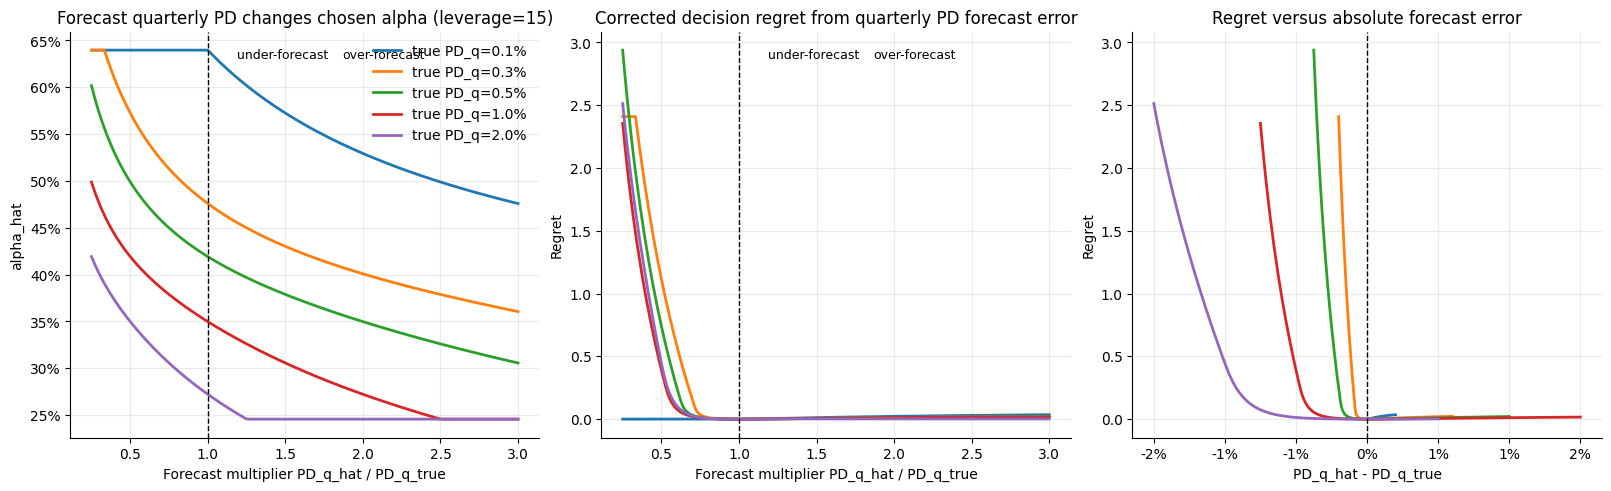

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for pd_true_value in true_pds:
    subset = forecast_diagnostics_df[forecast_diagnostics_df["pd_true_quarterly"] == pd_true_value]
    label = f"true PD_q={100 * pd_true_value:.1f}%"
    axes[0].plot(subset["forecast_multiplier"], subset["alpha_hat"], lw=2, label=label)
    axes[1].plot(subset["forecast_multiplier"], subset["regret"], lw=2, label=label)
    axes[2].plot(subset["forecast_error"], subset["regret"], lw=2, label=label)

for ax in axes[:2]:
    ax.axvline(1, color="black", lw=1, ls="--")
    ax.text(0.55, 0.96, "under-forecast", transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.text(0.58, 0.96, "over-forecast", transform=ax.transAxes, ha="left", va="top", fontsize=9)

axes[0].set_title(f"Forecast quarterly PD changes chosen alpha (leverage={leverage:g})")
axes[0].set_xlabel("Forecast multiplier PD_q_hat / PD_q_true")
axes[0].set_ylabel("alpha_hat")
percent_axis(axes[0], "y")

axes[1].set_title("Corrected decision regret from quarterly PD forecast error")
axes[1].set_xlabel("Forecast multiplier PD_q_hat / PD_q_true")
axes[1].set_ylabel("Regret")

axes[2].axvline(0, color="black", lw=1, ls="--")
axes[2].set_title("Regret versus absolute forecast error")
axes[2].set_xlabel("PD_q_hat - PD_q_true")
axes[2].set_ylabel("Regret")
percent_axis(axes[2], "x")

axes[0].legend()
plt.show()

### 10.2 Regret heatmap over true quarterly PD and forecast quarterly PD

The heatmap below evaluates corrected regret over pairs `(pd_true_quarterly, pd_hat_quarterly)`. The x-axis is the forecasted quarterly PD used to choose the action. The y-axis is the true quarterly PD used to judge the consequence. The diagonal is the perfect-forecast line and should have approximately zero regret.

In [138]:
regret_heatmap_n = 60  # increase toward 80 for a smoother but slower heatmap
pd_true_heatmap_grid = np.linspace(pd_quarterly_min, pd_quarterly_max, regret_heatmap_n)
pd_hat_heatmap_grid = np.linspace(pd_quarterly_min, pd_quarterly_max, regret_heatmap_n)

regret_grid_results = evaluate_regret_grid(
    pd_true_heatmap_grid,
    pd_hat_heatmap_grid,
    rho_mode=rho_mode,
    rho_fixed=rho_fixed,
    alpha_grid=forecast_alpha_grid,
    y=y,
    lambda_penalty=lambda_penalty,
    leverage=leverage,
    penalty_type="linear",
)

regret_matrix = regret_grid_results["regret_matrix"]
alpha_oracle_matrix = regret_grid_results["alpha_oracle_matrix"]
alpha_hat_matrix = regret_grid_results["alpha_hat_matrix"]
allocation_distortion_matrix = regret_grid_results["allocation_distortion_matrix"]
utility_oracle_matrix = regret_grid_results["utility_oracle_matrix"]
utility_hat_matrix = regret_grid_results["utility_hat_matrix"]

In [139]:
print("Minimum regret:", np.nanmin(regret_matrix))
print("Maximum regret:", np.nanmax(regret_matrix))
print("Fraction approximately zero:", np.mean(np.isclose(regret_matrix, 0.0, atol=1e-10)))

assert np.nanmin(regret_matrix) > -1e-9

diag_regrets = np.diag(regret_matrix)
print("Maximum diagonal regret:", np.nanmax(np.abs(diag_regrets)))
assert np.nanmax(np.abs(diag_regrets)) < 1e-8

Minimum regret: 0.0
Maximum regret: 10.45707263407236
Fraction approximately zero: 0.02277777777777778
Maximum diagonal regret: 0.0


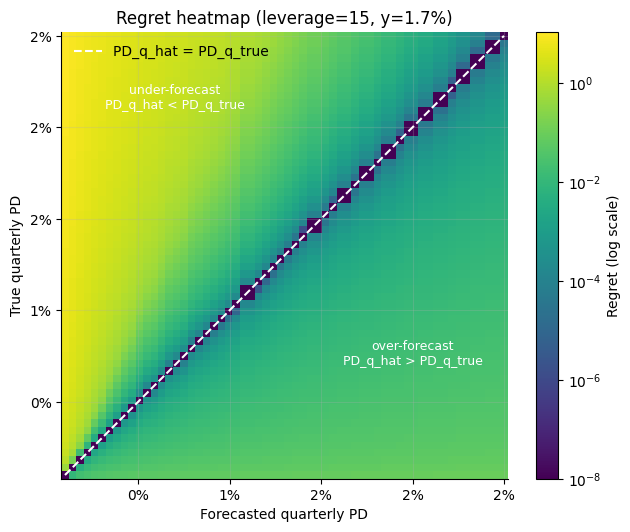

In [140]:
from matplotlib.colors import LogNorm


fig, ax = plt.subplots(figsize=(7.2, 5.8))
regret_for_plot = regret_matrix + 1e-8
mesh = ax.pcolormesh(
    pd_hat_heatmap_grid,
    pd_true_heatmap_grid,
    regret_for_plot,
    shading="auto",
    cmap="viridis",
    norm=LogNorm(vmin=max(1e-8, regret_for_plot.min()), vmax=regret_for_plot.max()),
)
fig.colorbar(mesh, ax=ax, label="Regret (log scale)")
ax.plot(pd_hat_heatmap_grid, pd_hat_heatmap_grid, color="white", lw=1.5, ls="--", label="PD_q_hat = PD_q_true")
ax.text(0.007, 0.021, "under-forecast\nPD_q_hat < PD_q_true", color="white", fontsize=9, ha="center")
ax.text(0.020, 0.007, "over-forecast\nPD_q_hat > PD_q_true", color="white", fontsize=9, ha="center")
ax.set_title(f"Regret heatmap (leverage={leverage:g}, y={100*y:.1f}%)")
ax.set_xlabel("Forecasted quarterly PD")
ax.set_ylabel("True quarterly PD")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend(loc="upper left")
plt.show()

### 10.3 Allocation distortion heatmap

This heatmap shows `alpha_hat - alpha_oracle`. Negative values mean the forecast-based model under-allocates relative to the oracle. Positive values mean it over-allocates relative to the oracle.

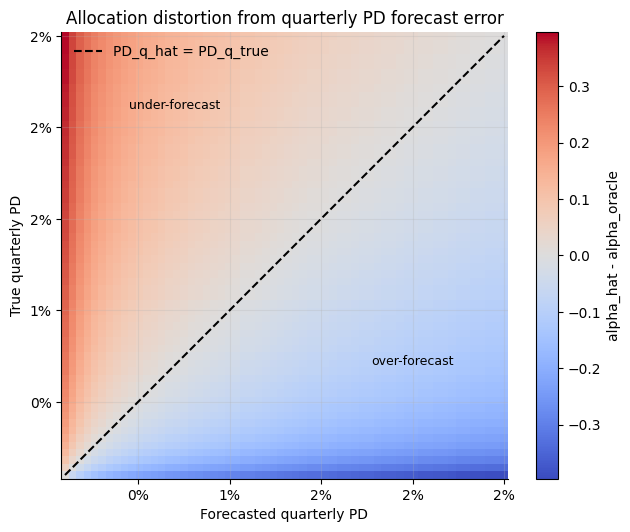

In [141]:
max_abs_distortion = np.nanmax(np.abs(allocation_distortion_matrix))

fig, ax = plt.subplots(figsize=(7.2, 5.8))
mesh = ax.pcolormesh(
    pd_hat_heatmap_grid,
    pd_true_heatmap_grid,
    allocation_distortion_matrix,
    shading="auto",
    cmap="coolwarm",
    vmin=-max_abs_distortion,
    vmax=max_abs_distortion,
)
fig.colorbar(mesh, ax=ax, label="alpha_hat - alpha_oracle")
ax.plot(pd_hat_heatmap_grid, pd_hat_heatmap_grid, color="black", lw=1.5, ls="--", label="PD_q_hat = PD_q_true")
ax.text(0.007, 0.021, "under-forecast", color="black", fontsize=9, ha="center")
ax.text(0.020, 0.007, "over-forecast", color="black", fontsize=9, ha="center")
ax.set_title("Allocation distortion from quarterly PD forecast error")
ax.set_xlabel("Forecasted quarterly PD")
ax.set_ylabel("True quarterly PD")
percent_axis(ax, "x")
percent_axis(ax, "y")
ax.legend(loc="upper left")
plt.show()

### 10.4 Decision-weighted loss curve

A symmetric prediction loss such as squared PD error can give the same penalty to over- and under-forecasting of the same magnitude. The downstream allocation problem usually does not. The curves below normalise squared prediction error and decision regret to a maximum of 1 for each fixed true PD.

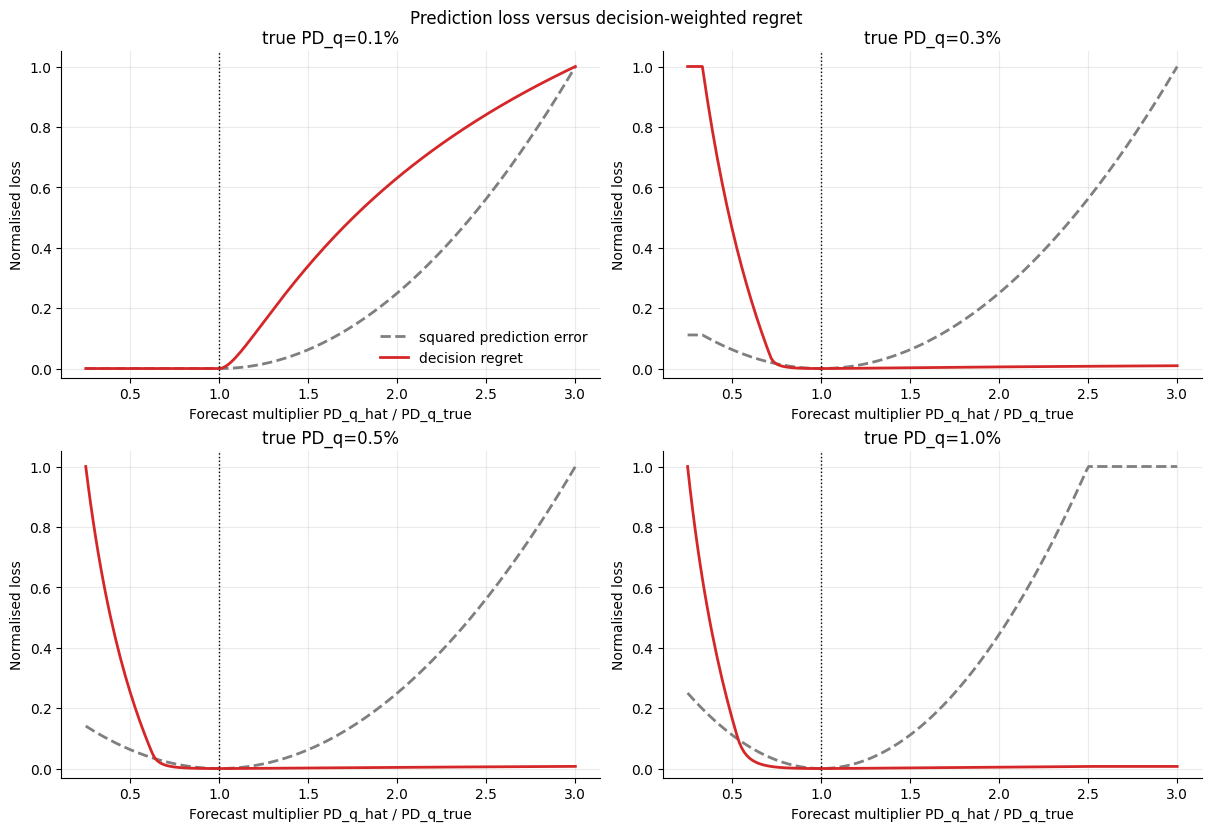

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

for ax, pd_true_value in zip(axes, true_pds):
    subset = forecast_diagnostics_df[forecast_diagnostics_df["pd_true_quarterly"] == pd_true_value].copy()
    prediction_error_squared = subset["forecast_error"].to_numpy() ** 2
    decision_regret = subset["regret"].to_numpy()

    pred_norm = prediction_error_squared / prediction_error_squared.max() if prediction_error_squared.max() > 0 else prediction_error_squared
    regret_norm = decision_regret / decision_regret.max() if decision_regret.max() > 0 else decision_regret

    ax.plot(subset["forecast_multiplier"], pred_norm, color="tab:gray", lw=2, ls="--", label="squared prediction error")
    ax.plot(subset["forecast_multiplier"], regret_norm, color="tab:red", lw=2, label="decision regret")
    ax.axvline(1, color="black", lw=1, ls=":")
    ax.set_title(f"true PD_q={100 * pd_true_value:.1f}%")
    ax.set_xlabel("Forecast multiplier PD_q_hat / PD_q_true")
    ax.set_ylabel("Normalised loss")
    ax.set_ylim(-0.03, 1.05)

axes[0].legend()
fig.suptitle("Prediction loss versus decision-weighted regret", y=1.02)
plt.show()

### Interpretation for PTO versus DFL

In a predict-then-optimise approach, the model is trained to minimise a prediction loss on PD, such as MSE or calibration error. This treats forecast errors symmetrically unless the loss is explicitly weighted.

However, the downstream allocation problem does not treat all PD errors equally. An under-forecast of PD may lead to excessive risky allocation and regulatory shortfall, while an over-forecast may lead to conservative under-allocation and opportunity cost. The regret heatmap visualises this decision-dependent error surface.

Decision-focused learning would train the predictive model using this downstream regret or utility loss directly, rather than only trying to make PD forecasts accurate in a statistical sense.

## Summary: what to look for

- `K_IRB(PD_annual)` rises nonlinearly because the regulatory capital formula combines annual default risk, tail confidence, correlation, and maturity adjustment.
- Basel corporate correlation `R(PD_annual)` changes with annual PD. In this notebook that annual PD is derived from quarterly PD.
- The Vasicek default threshold uses quarterly PD, while the tail thickness from rho uses annual PD in the Basel-implied baseline.
- High quarterly PD reduces alpha through direct expected quarterly losses and through the regulatory shortfall penalty when losses exceed the threshold.
- Larger `lambda_penalty` lowers risky allocation, larger yield raises it, and fixed-rho experiments help separate correlation mechanics from the Basel-implied case.

In [1]:
true_pds

NameError: name 'true_pds' is not defined

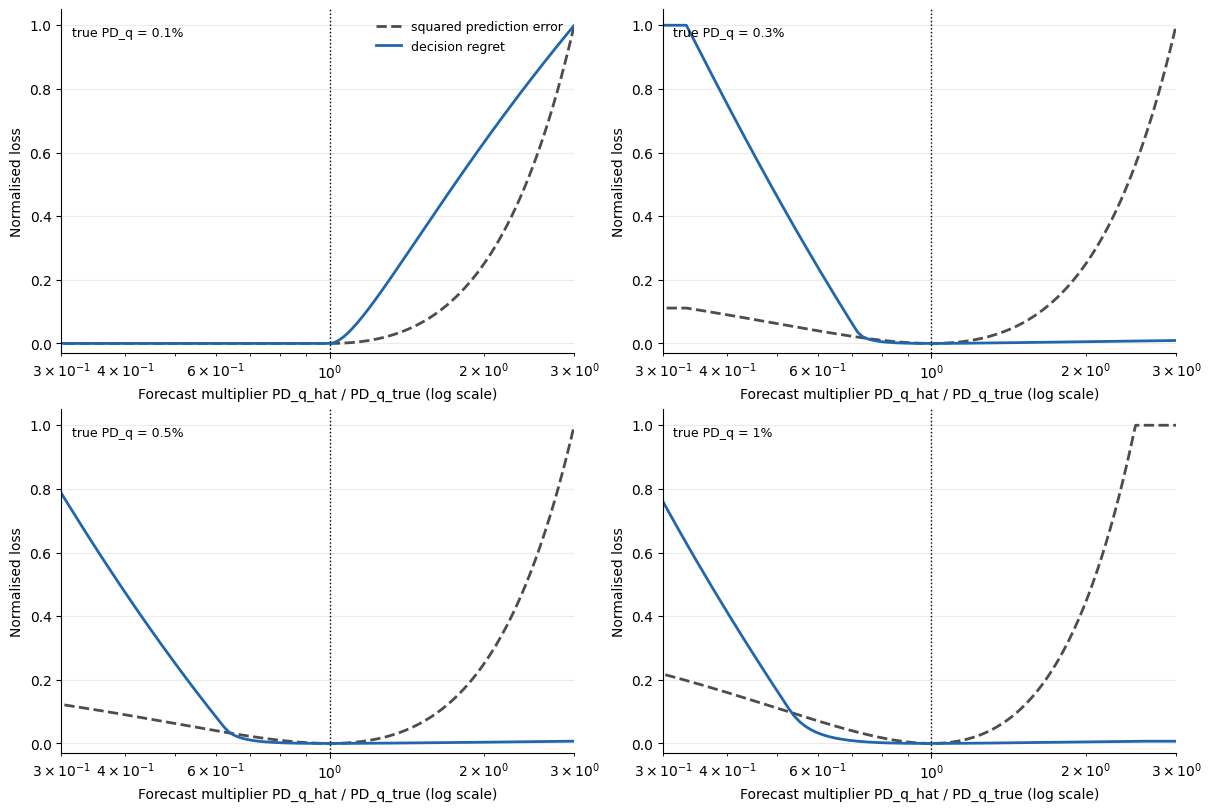

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.ravel()

plot_pds = true_pds[:4]  # or pick 4 explicitly, e.g. drop the middle one to keep 0.001..0.020

for ax, pd_true_value in zip(axes, plot_pds):
    subset = forecast_diagnostics_df[forecast_diagnostics_df["pd_true_quarterly"] == pd_true_value].copy()
    prediction_error_squared = subset["forecast_error"].to_numpy() ** 2
    decision_regret = subset["regret"].to_numpy()

    pred_norm = prediction_error_squared / prediction_error_squared.max() if prediction_error_squared.max() > 0 else prediction_error_squared
    regret_norm = decision_regret / decision_regret.max() if decision_regret.max() > 0 else decision_regret

    ax.plot(subset["forecast_multiplier"], pred_norm, color="#4d4d4d", lw=2, ls="--", label="squared prediction error")
    ax.plot(subset["forecast_multiplier"], regret_norm, color="#2166ac", lw=2, label="decision regret")
    ax.axvline(1, color="black", lw=1, ls=":")

    ax.set_xscale("log")
    ax.set_xlim(0.3, 3.0)
    ax.set_ylim(-0.03, 1.05)
    ax.set_xlabel("Forecast multiplier PD_q_hat / PD_q_true (log scale)")
    ax.set_ylabel("Normalised loss")
    ax.text(0.02, 0.95, f"true PD_q = {100 * pd_true_value:.2g}%", transform=ax.transAxes, va="top", fontsize=9)

axes[0].legend(loc="upper right", fontsize=9)
plt.show()